Slope: -0.004827 V/A
Load Regulation: 4.827 uV/mA


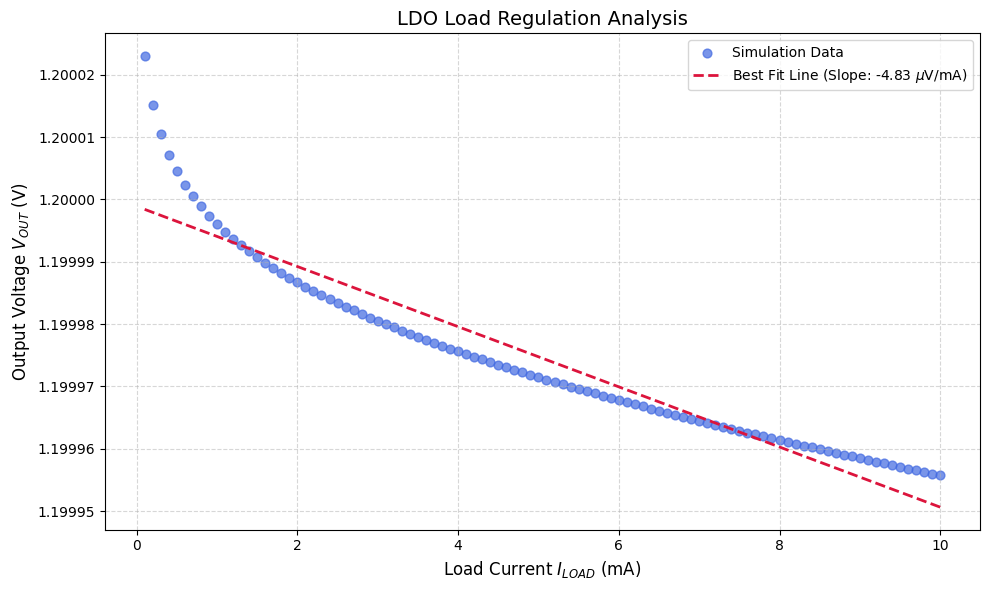

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
# Adjust the filename to match your exported CSV
file_path = 'load_reg.csv'
df = pd.read_csv(file_path)

# 2. Extract data (Assuming the column names you provided)
# X is Current in Amps, Y is Voltage in Volts
i_load_amps = df['VDC("/Vout") X'].values
v_out = df['VDC("/Vout") Y'].values

# 3. Calculate Linear Line of Best Fit (y = mx + b)
# np.polyfit returns [slope, intercept]
slope, intercept = np.polyfit(i_load_amps, v_out, 1)
v_out_fit = slope * i_load_amps + intercept

# 4. Convert units for the report
# Load Regulation is often reported in uV/mA
# (V/A) * (1,000,000 uV / 1 V) * (1 A / 1,000 mA) = V/A * 1000
load_reg_uv_ma = slope * 1000

print(f"Slope: {slope:.6f} V/A")
print(f"Load Regulation: {abs(load_reg_uv_ma):.3f} uV/mA")

# 5. Plotting
plt.figure(figsize=(10, 6))

# Plot actual simulation points
plt.scatter(i_load_amps * 1000, v_out, color='royalblue', label='Simulation Data', s=40, alpha=0.7)

# Plot the best fit line
plt.plot(i_load_amps * 1000, v_out_fit, color='crimson', linestyle='--', linewidth=2, label=f'Best Fit Line (Slope: {load_reg_uv_ma:.2f} $\\mu$V/mA)')

# Formatting
plt.title('LDO Load Regulation Analysis', fontsize=14)
plt.xlabel('Load Current $I_{LOAD}$ (mA)', fontsize=12)
plt.ylabel('Output Voltage $V_{OUT}$ (V)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=10)

# Ensure the Y-axis doesn't use scientific notation for small offsets
plt.ticklabel_format(useOffset=False, style='plain')

plt.tight_layout()
plt.savefig('ldo_load_regulation_plot.png', dpi=300)
plt.show()

Slope: 0.00000587 V/V
Line Regulation: 5.875 uV/V


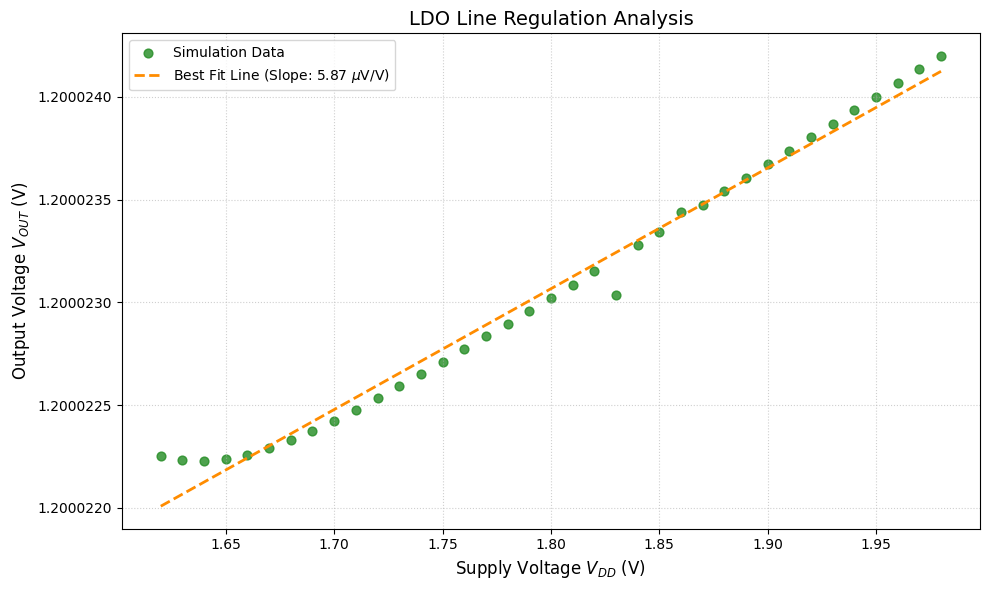

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the line regulation data
file_path = 'line_reg_01m.csv'
df = pd.read_csv(file_path)

# 2. Extract data (Column 1 = VDD, Column 2 = Vout)
v_dd = df['VDC("/Vout") X'].values
v_out = df['VDC("/Vout") Y'].values

# 3. Calculate Linear Line of Best Fit
# Slope here is in Volts per Volt (V/V)
slope, intercept = np.polyfit(v_dd, v_out, 1)
v_out_fit = slope * v_dd + intercept

# 4. Convert units to microvolts per Volt (uV/V)
line_reg_uv_v = slope * 1e6

print(f"Slope: {slope:.8f} V/V")
print(f"Line Regulation: {line_reg_uv_v:.3f} uV/V")

# 5. Plotting
plt.figure(figsize=(10, 6))

plt.scatter(v_dd, v_out, color='forestgreen', label='Simulation Data', s=40, alpha=0.8)
plt.plot(v_dd, v_out_fit, color='darkorange', linestyle='--', linewidth=2, 
         label=f'Best Fit Line (Slope: {line_reg_uv_v:.2f} $\\mu$V/V)')

# Formatting
plt.title('LDO Line Regulation Analysis', fontsize=14)
plt.xlabel('Supply Voltage $V_{DD}$ (V)', fontsize=12)
plt.ylabel('Output Voltage $V_{OUT}$ (V)', fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc='best')

# Clean up axis formatting
plt.ticklabel_format(useOffset=False, style='plain')

plt.tight_layout()
plt.savefig('ldo_line_regulation_plot_01m.png', dpi=300)
plt.show()

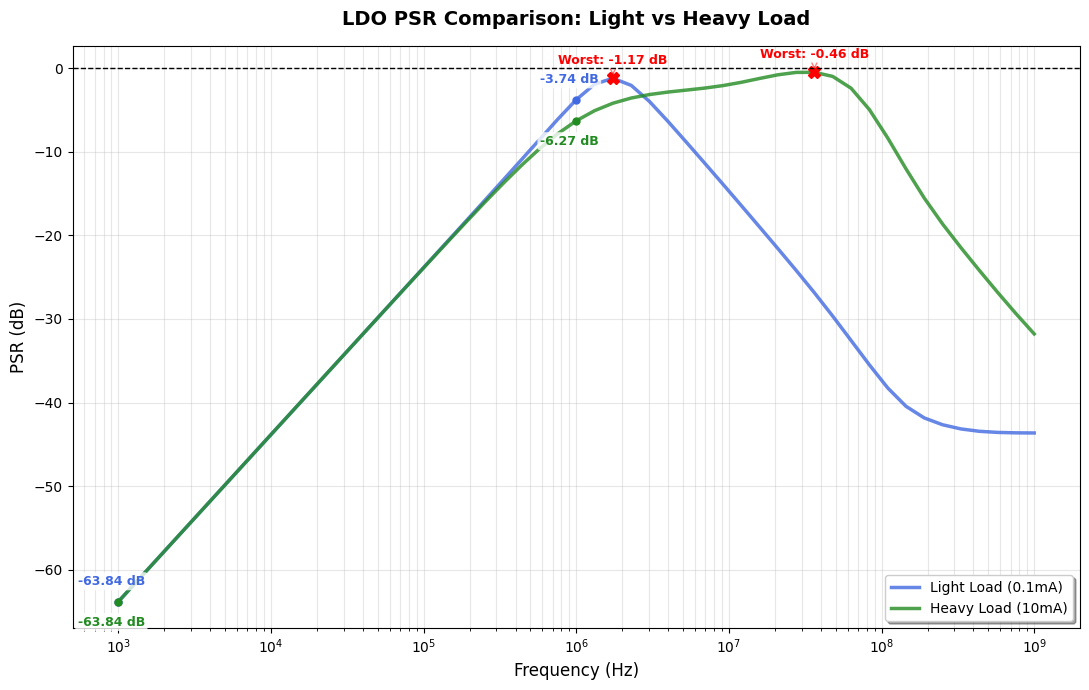

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File paths - update these to your actual CSV names
files = {
    'Light Load (0.1mA)': 'psr_01m.csv',
    'Heavy Load (10mA)': 'psr_10m.csv'
}

plt.figure(figsize=(11, 7))

def process_psr(file_path, label, color, label_offset):
    df = pd.read_csv(file_path)
    freq = df.iloc[:, 0].values
    psr = df.iloc[:, 1].values
    
    # Plot the curve
    plt.semilogx(freq, psr, label=label, color=color, linewidth=2.5, alpha=0.8)
    
    # Labels for 1k and 1M
    for f_target in [1000, 1000000]:
        # Exact match logic
        mask = np.isclose(freq, f_target, rtol=1e-5)
        if any(mask):
            val = psr[mask][0]
            plt.plot(f_target, val, 'o', color=color, markersize=5)
            
            # Offset labels: label_offset=1 (up), -1 (down)
            plt.annotate(f'{val:.2f} dB', 
                         xy=(f_target, val), 
                         xytext=(-5, 10 * label_offset), 
                         textcoords="offset points", 
                         ha='center', 
                         va='bottom' if label_offset > 0 else 'top',
                         fontsize=9, fontweight='bold', color=color,
                         bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8, ec='none'))

    # Worst Case (Maximum value)
    worst_idx = np.argmax(psr)
    w_freq, w_val = freq[worst_idx], psr[worst_idx]
    
    plt.plot(w_freq, w_val, 'X', color='red', markersize=9)
    plt.annotate(f'Worst: {w_val:.2f} dB', 
                 xy=(w_freq, w_val), 
                 xytext=(0, 10), 
                 textcoords="offset points", 
                 arrowprops=dict(arrowstyle='->', color='red', alpha=0.5),
                 fontsize=9, fontweight='bold', color='red', ha='center')

# Run for both loads
# We use '1' for the first file (labels go up) and '-1' for the second (labels go down)
process_psr(files['Light Load (0.1mA)'], 'Light Load (0.1mA)', 'royalblue', 1)
process_psr(files['Heavy Load (10mA)'], 'Heavy Load (10mA)', 'forestgreen', -1)

# Final Styling
plt.title('LDO PSR Comparison: Light vs Heavy Load', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('PSR (dB)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.axhline(0, color='black', linewidth=1, linestyle='--') # 0dB Reference
plt.legend(loc='lower right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

Light (0.1mA) -> DC: 94.8dB, UGBW: 1.25MHz, PM: 61.1°, GM: 32.7dB
Heavy (10mA) -> DC: 90.5dB, UGBW: 1.46MHz, PM: 100.2°, GM: 23.9dB


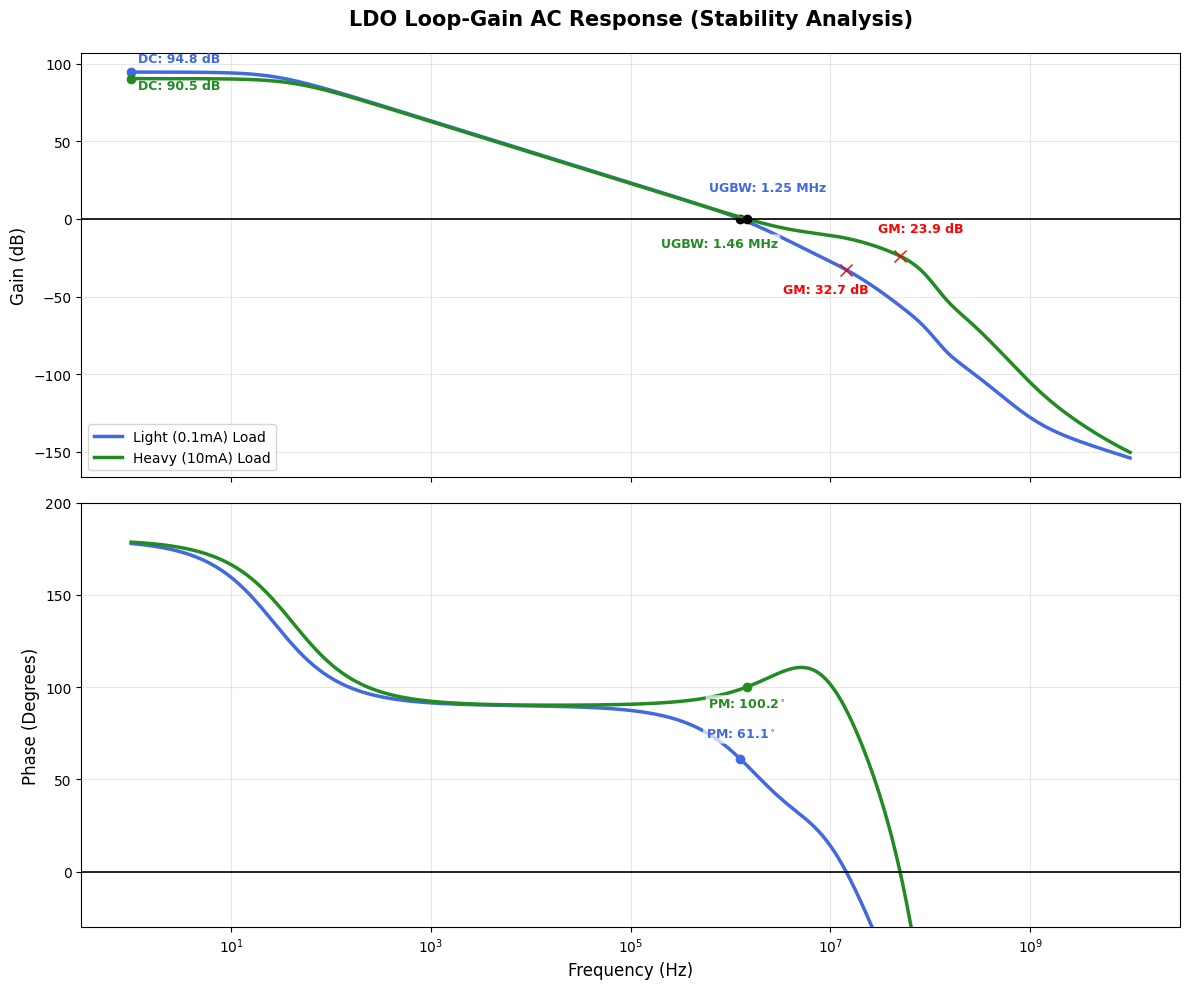

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File names - Update these to match your local files
files = {
    'Light (0.1mA)': {'gain': 'loop_gain_01m.csv', 'phase': 'loop_phase_01m.csv'},
    'Heavy (10mA)': {'gain': 'loop_gain_10m.csv', 'phase': 'loop_phase_10m.csv'}
}

# Create a figure with two subplots (Magnitude and Phase)
fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

def plot_stability(load_name, color, direction):
    # 1. Load the data
    g_df = pd.read_csv(files[load_name]['gain'])
    p_df = pd.read_csv(files[load_name]['phase'])
    
    freq = g_df.iloc[:, 0].values
    gain = g_df.iloc[:, 1].values
    phase = p_df.iloc[:, 1].values
    
    # 2. Extract Key Metrics
    # DC Gain (at the first frequency point, 1Hz)
    dc_gain = gain[0]
    
    # UGBW (Gain crosses 0dB)
    # Using interp for precision since exact 0dB point is likely between simulation steps
    ugbw = np.interp(0, gain[::-1], freq[::-1])
    
    # Phase Margin (Phase at UGBW)
    pm_val = np.interp(ugbw, freq, phase)
    
    # Gain Margin (Gain when Phase crosses 0)
    # We find frequency where phase = 0, then look up gain at that frequency
    f_phase_zero = np.interp(0, phase[::-1], freq[::-1])
    gain_at_zero_phase = np.interp(f_phase_zero, freq, gain)
    gm_val = abs(gain_at_zero_phase) # GM is reported as the positive "distance" from 0dB

    # 3. Plot Magnitude Response
    ax_mag.semilogx(freq, gain, label=f'{load_name} Load', color=color, linewidth=2.5)
    
    # Mark DC Gain
    ax_mag.plot(freq[0], dc_gain, 'o', color=color, markersize=6)
    ax_mag.annotate(f'DC: {dc_gain:.1f} dB', xy=(freq[0], dc_gain), 
                    xytext=(5, 7.5 * direction), textcoords='offset points',
                    color=color, fontweight='bold', fontsize=9)
    
    # Mark UGBW
    ax_mag.plot(ugbw, 0, 'o', color='black', markersize=6)
    ax_mag.annotate(f'UGBW: {ugbw/1e6:.2f} MHz', xy=(ugbw, 0), 
                    xytext=(20* direction, 20 * direction), textcoords='offset points',
                    ha='center', color=color, fontweight='bold', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

    # Mark Gain Margin
    ax_mag.plot(f_phase_zero, gain_at_zero_phase, 'x', color='red', markersize=8)
    ax_mag.annotate(f'GM: {gm_val:.1f} dB', xy=(f_phase_zero, gain_at_zero_phase), 
                    xytext=(15* -direction, -17 * direction), textcoords='offset points',
                    ha='center', color='red', fontweight='bold', fontsize=9)

    # 4. Plot Phase Response
    ax_phase.semilogx(freq, phase, label=f'{load_name} Load', color=color, linewidth=2.5)
    
    # Mark Phase Margin point
    ax_phase.plot(ugbw, pm_val, 'o', color=color, markersize=6)
    ax_phase.annotate(f'PM: {pm_val:.1f}$^\\circ$', xy=(ugbw, pm_val), 
                      xytext=(0, 15 * direction), textcoords='offset points',
                      ha='center', color=color, fontweight='bold', fontsize=9,
                      bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))
    
    print(f"{load_name} -> DC: {dc_gain:.1f}dB, UGBW: {ugbw/1e6:.2f}MHz, PM: {pm_val:.1f}°, GM: {gm_val:.1f}dB")

# Run for both loads
# direction=1 pushes labels UP, direction=-1 pushes labels DOWN
plot_stability('Light (0.1mA)', 'royalblue', 1)
plot_stability('Heavy (10mA)', 'forestgreen', -1)

# Formatting - Magnitude
ax_mag.set_title('LDO Loop-Gain AC Response (Stability Analysis)', fontsize=15, fontweight='bold', pad=20)
ax_mag.set_ylabel('Gain (dB)', fontsize=12)
ax_mag.grid(True, which="both", ls="-", alpha=0.3)
ax_mag.axhline(0, color='black', linewidth=1.2)
ax_mag.legend(loc='lower left')

# Formatting - Phase
ax_phase.set_xlabel('Frequency (Hz)', fontsize=12)
ax_phase.set_ylabel('Phase (Degrees)', fontsize=12)
ax_phase.grid(True, which="both", ls="-", alpha=0.3)
ax_phase.axhline(0, color='black', linewidth=1.2)
ax_phase.set_ylim(-30, 200) # Adjust if your phase goes higher/lower

plt.tight_layout()
# plt.savefig('ldo_full_stability_plot.png', dpi=300)
plt.show()

In [7]:
import re
import pandas as pd
import numpy as np

def parse_si_value(value_str):
    if pd.isna(value_str) or value_str == 'nan':
        return np.nan
    
    multipliers = {
        'u': 1e-6, 'm': 1e-3, 'K': 1e3, 'k': 1e3, 
        'n': 1e-9, 'f': 1e-15, 'p': 1e-12, 'a': 1e-18, 
        'G': 1e9, 'M': 1e6
    }
    match = re.match(r'([-+0-9.]+)([a-zA-Z]?)', str(value_str).strip())
    if not match: return np.nan
    
    number = float(match.group(1))
    unit = match.group(2)
    return number * multipliers.get(unit, 1)

def format_si_value(value, unit_suffix=""):
    if pd.isna(value) or value == 0: return "0"
    abs_val = abs(value)
    
    if abs_val >= 1e6: res = f"{abs_val/1e6:.2f}\\,M"
    elif abs_val >= 1e3: res = f"{abs_val/1e3:.2f}\\,k"
    elif abs_val >= 1:   res = f"{abs_val:.2f}\\,"
    elif abs_val >= 1e-3: res = f"{abs_val/1e-3:.2f}\\,m"
    elif abs_val >= 1e-6: res = f"{abs_val/1e-6:.2f}\\,\\mu"
    elif abs_val >= 1e-9: res = f"{abs_val/1e-9:.2f}\\,n"
    else: res = f"{abs_val:.2e}\\,"
    
    return f"${res}{unit_suffix}$"

def process_op_file(file_path):
    with open(file_path, 'r') as f:
        content = f.read()

    blocks = re.split(r'\n(?=/)', content)
    data = []
    
    for block in blocks:
        if not block.strip(): continue
        
        full_path = block.split('\n')[0].strip()
        device_name = full_path.split('/')[-1] 
        
        # Extract model name specifically
        model_match = re.search(r'model\s*=\s*(\w+)', block)
        model_name = model_match.group(1) if model_match else "unknown"
        
        matches = re.findall(r'(\w+)\s*=\s*([-+0-9.a-zA-Z]+)', block)
        block_dict = {k: parse_si_value(v) for k, v in matches}
        
        if 'ids' not in block_dict: continue
            
        id_mag = abs(block_dict.get('ids', 0))
        gm_mag = abs(block_dict.get('gm', 0))
        vov_mag = abs(block_dict.get('vgs', 0) - block_dict.get('vth', 0))

        # Determine type label based on model suffix (P or N)
        dev_type = "PMOS" if model_name.endswith('P') else "NMOS"

        data.append({
            'Type': dev_type,
            'Device': device_name,
            'Size (W/L)': '---',
            'ID': format_si_value(id_mag, "A"),
            'gm': format_si_value(gm_mag, "S"),
            'Vov': format_si_value(vov_mag, "V")
        })
        
    df = pd.DataFrame(data)
    
    # Sort: PMOS first, then NMOS, then by Device name
    df['Type_Sort'] = df['Type'].apply(lambda x: 0 if x == 'PMOS' else 1)
    df = df.sort_values(by=['Type_Sort', 'Device']).drop(columns=['Type_Sort'])
    
    return df

# --- Execution ---
df = process_op_file('dc_op_ldo.txt')

# Generate LaTeX Table Code
latex_table = df.to_latex(index=False, 
                          column_format='llcccc',
                          caption='Transistor Operating Point Summary by Device Type',
                          label='tab:op_points',
                          escape=False)

print(latex_table)

\begin{table}
\caption{Transistor Operating Point Summary by Device Type}
\label{tab:op_points}
\begin{tabular}{llcccc}
\toprule
Type & Device & Size (W/L) & ID & gm & Vov \\
\midrule
PMOS & P10 & --- & $24.87\,\muA$ & $495.00\,\muS$ & $36.60\,mV$ \\
PMOS & P13 & --- & $24.87\,\muA$ & $495.00\,\muS$ & $36.60\,mV$ \\
PMOS & P14 & --- & $5.37\,\muA$ & $97.48\,\muS$ & $71.80\,mV$ \\
PMOS & P15 & --- & $5.37\,\muA$ & $97.53\,\muS$ & $71.80\,mV$ \\
PMOS & P16 & --- & $10.00\,\muA$ & $153.70\,\muS$ & $108.30\,mV$ \\
PMOS & P18 & --- & $10.01\,\muA$ & $154.60\,\muS$ & $106.10\,mV$ \\
PMOS & P19 & --- & $49.74\,\muA$ & $801.90\,\muS$ & $95.60\,mV$ \\
PMOS & P20 & --- & $5.37\,\muA$ & $105.50\,\muS$ & $49.50\,mV$ \\
PMOS & P21 & --- & $5.37\,\muA$ & $105.50\,\muS$ & $49.50\,mV$ \\
PMOS & P22 & --- & $49.74\,\muA$ & $587.90\,\muS$ & $160.30\,mV$ \\
PMOS & P23 & --- & $10.00\,\muA$ & $118.70\,\muS$ & $160.30\,mV$ \\
PMOS & P24 & --- & $10.01\,\muA$ & $118.80\,\muS$ & $160.30\,mV$ \\
PMOS & P9 & -